### STEP1: LOAD THE SAVED PICKLE FILE

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import time

In [3]:
df_la_daily=pd.read_pickle("processed_data/la_daily.pkl")
df_la_daily_2023=pd.read_pickle("processed_data/la_daily_2023.pkl")

print(df_la_daily.head())
print(df_la_daily_2023.head())

            pm25_cf_1   humidity   pressure  temperature  roll_mean  roll_std
date                                                                         
2017-01-01  25.714433  54.929449  59.433218    59.433115        NaN       NaN
2017-01-02   7.568054  53.618319  61.726110    61.723596        NaN       NaN
2017-01-03  18.169412  52.460524  62.954285    62.956328        NaN       NaN
2017-01-04  21.875172  51.506422  63.943135    63.944057        NaN       NaN
2017-01-05  16.650620  65.335559  65.899936    65.901941        NaN       NaN
            pm25_cf_1   humidity    pressure  temperature
date                                                     
2023-01-01   3.141628  54.717333  980.710695    62.494658
2023-01-02   5.587807  46.514813  986.092032    59.328038
2023-01-03   4.073468  58.732813  989.230255    60.382105
2023-01-04   4.772066  63.754123  990.898813    63.695953
2023-01-05   3.320873  60.584210  988.926191    63.454326


### STEP2: Apply ADF Stationarity Test

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_la_daily['pm25_cf_1'])
print(result[1])  # p-value
if result[1] < 0.05:
    print(f"\n  RESULT: STATIONARY (p-value = {result[1]:.6f} < 0.05)")
    print(f"    We REJECT the null hypothesis of a unit root.")
else:
    print(f"\n  RESULT: NON-STATIONARY (p-value = {result[1]:.6f} >= 0.05)")
    print(f"    We FAIL TO REJECT the null hypothesis of a unit root.")


9.058169231618667e-16

  RESULT: STATIONARY (p-value = 0.000000 < 0.05)
    We REJECT the null hypothesis of a unit root.


The data is stationary and does not need differenciating. (d=0)

### STEP3: PLOT ACF/PACF 

<Figure size 1000x500 with 0 Axes>

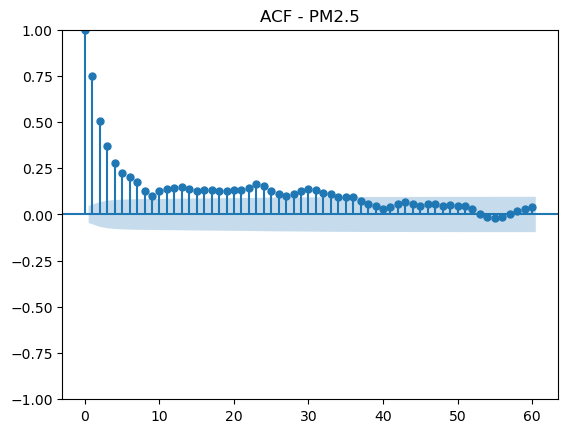

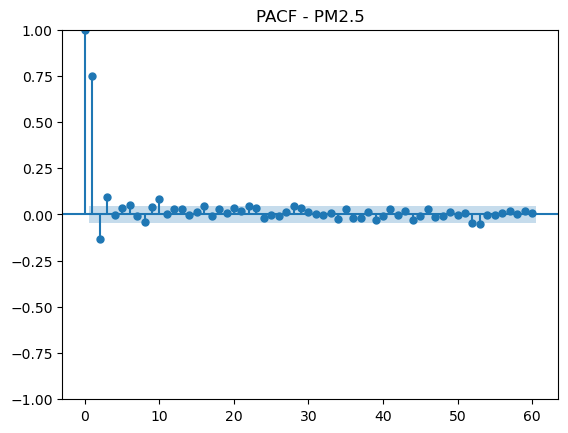

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df_la_daily['pm25_cf_1']

plt.figure(figsize=(10,5))
plot_acf(series, lags=60)
plt.title("ACF - PM2.5")
plt.show()

plot_pacf(series, lags=60)
plt.title("PACF - PM2.5")
plt.show()

ACF shows gradual decay, no sharp cutoff  ans suggests AR behaviour
PACF: very strong spike at lag 1 and mostly inside confidence band.

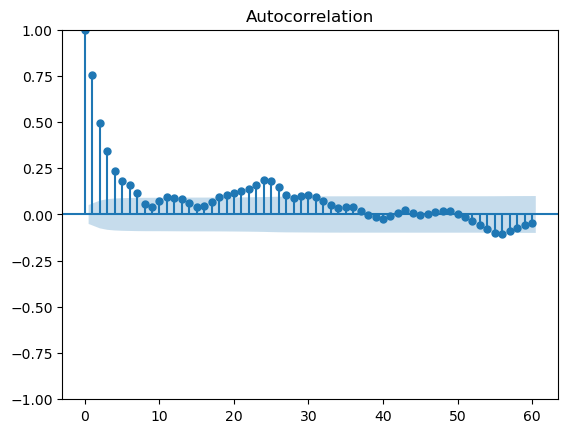

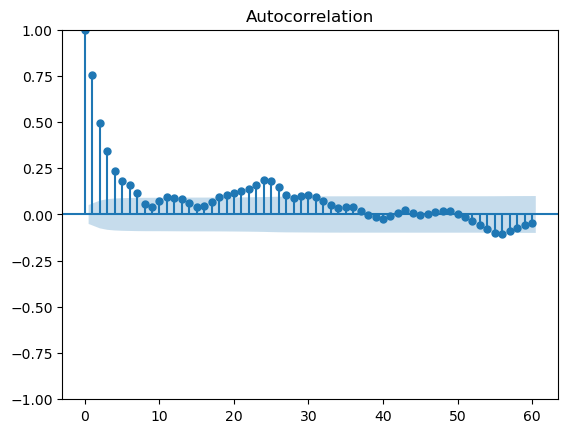

In [6]:
series_seasonal_diff = series.diff(365).dropna()
plot_acf(series_seasonal_diff, lags=60)

order = (1,0,0)    ?
seasonal_order = (1,0,0,365)

In [7]:
df_la_daily.index = pd.to_datetime(df_la_daily.index)
df_la_daily.sort_index(inplace=True)
df_la_daily = df_la_daily.asfreq('D')

df_train = df_la_daily.loc['2017-01-01':'2020-12-31', 'pm25_cf_1']
df_test_2021 = df_la_daily.loc['2021-01-01':'2021-12-31', 'pm25_cf_1']

print(df_train.shape)
print(df_test_2021.shape)
print(df_train.head())
print(df_test_2021.head())

(1461,)
(365,)
date
2017-01-01    25.714433
2017-01-02     7.568054
2017-01-03    18.169412
2017-01-04    21.875172
2017-01-05    16.650620
Freq: D, Name: pm25_cf_1, dtype: float64
date
2021-01-01    19.619121
2021-01-02    12.875160
2021-01-03    23.690234
2021-01-04    22.526849
2021-01-05    27.770392
Freq: D, Name: pm25_cf_1, dtype: float64


### FIT SARIMAX

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_train.dropna()


model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,365),
    enforce_stationarity=False,
    enforce_invertibility=False
)


start_time=time.time()

results = model.fit()

end_time=time.time()

print(f"Model running time: {end_time - start_time:.2f} seconds")
print(results.summary())

Model running time: 119.61 seconds
                                      SARIMAX Results                                      
Dep. Variable:                           pm25_cf_1   No. Observations:                 1461
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 365)   Log Likelihood               -3773.605
Date:                             Mon, 02 Mar 2026   AIC                           7553.210
Time:                                     23:42:12   BIC                           7568.205
Sample:                                 01-01-2017   HQIC                          7558.884
                                      - 12-31-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8902      0.007    131.822      0.000       0.877     

**Interpretation**
ar.L1 = 0.8902  means short term effect is high.

ar.S.L365 = 0.0612 means seasonality exists but weak relative to short-term persistence.



 Manual SARIMAX Performance (Test Set) 
RMSE: 14.65
MAE: 11.90
MAPE: 88.41%


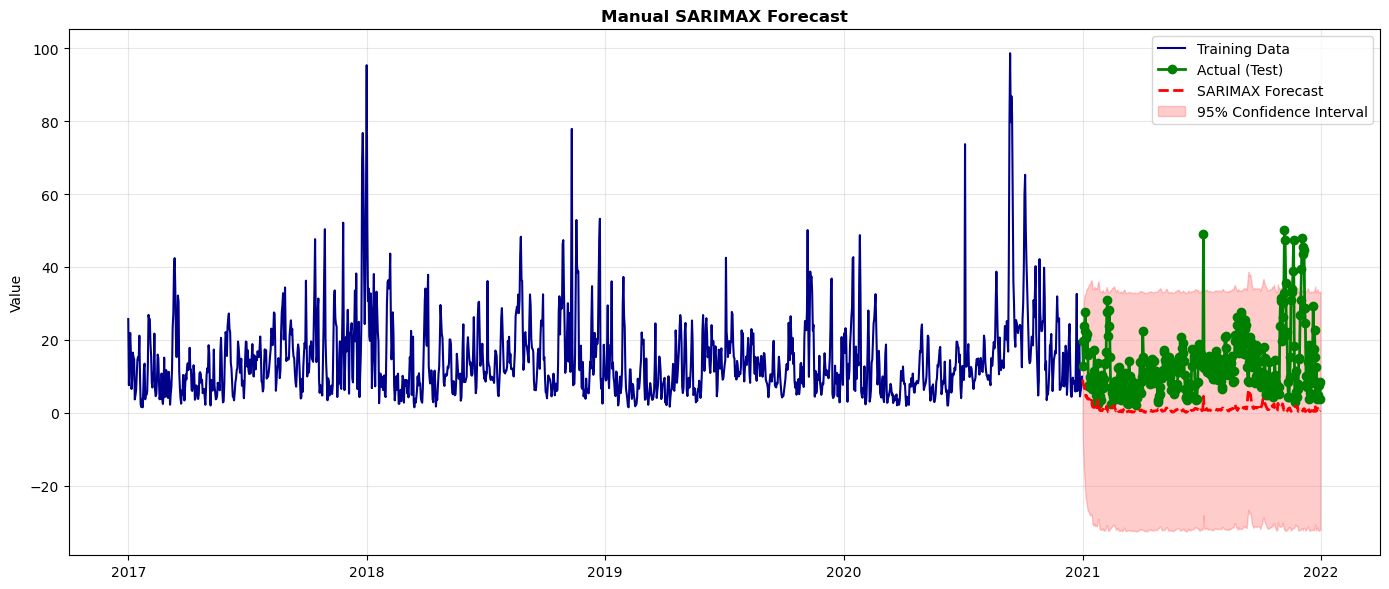

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Forecast on test set
forecast_manual = results.get_forecast(steps=len(df_test_2021))
forecast_mean = forecast_manual.predicted_mean
forecast_ci = forecast_manual.conf_int()
    
# Evaluate
rmse = np.sqrt(mean_squared_error(df_test_2021, forecast_mean))
mae = mean_absolute_error(df_test_2021, forecast_mean)
mape = np.mean(np.abs((df_test_2021 - forecast_mean) / df_test_2021)) * 100
    
print(f"\n Manual SARIMAX Performance (Test Set) ")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
    
# Visualize
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train, label='Training Data', color='darkblue')
plt.plot(df_test_2021.index, df_test_2021, label='Actual (Test)', color='green', linewidth=2, marker='o')
plt.plot(df_test_2021.index, forecast_mean, label='SARIMAX Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(df_test_2021.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                     color='red', alpha=0.2, label='95% Confidence Interval')
plt.title(f'Manual SARIMAX Forecast', fontweight='bold', fontsize=12)
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Average PM2.5 level in 2021
print(df_test_2021.mean())

13.037048289057536


### Naive Baseline

In [13]:
naive_pred = df_test_2021.shift(1)
naive_mae = mean_absolute_error(df_test_2021[1:], naive_pred[1:])
print("Naive MAE:", naive_mae)

Naive MAE: 3.8309002842087914
